# Análisis de Datos Faltantes y Limpieza de Dataset
### Autor: Angelo Ibaceta
### Ingeniería Civil Informática -- UTFSM

Competencia de kaggle: [Climate Change: Earth Surface Temperature Data](https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data/data)

# Requerimientos
- pandas
- matplotlib
- seaborn

# Contexto

Este data set es producto del estudio de tendencias climáticas de un largo tiempo (1750 hasta 2013), que kaggle juntó de diversas fuentes, limpiados y ajustados.

Según se indica en la página de [kaggle](https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data) la fuente de los datos, este dataset es una colleción de varios otros dataset y archivos:
- NOAA’s MLOST, NASA’s GISTEMP and the UK’s HadCrut data sets
- estudio de Berkeley Earth , afiliado con Lawrence Berkeley National Laboratory, que combinó 16 archivos pre-existentes 

Los archivos disponibles son:
- Global Land and Ocean-and-Land Temperatures (GlobalTemperatures.csv)
- Global Average Land Temperature by Country (GlobalLandTemperaturesByCountry.csv) $\leftarrow$ con este trabajamos
- Global Average Land Temperature by State (GlobalLandTemperaturesByState.csv)
- Global Land Temperatures By Major City (GlobalLandTemperaturesByMajorCity.csv)
- Global Land Temperatures By City (GlobalLandTemperaturesByCity.csv)

Algunas cosas a tener en cuenta:
- Los primeros datos, entre 1750 a 1850, fueron tomados usando **termómetros de mercurio**, los cuales tenían el problema de que estos son muy sensibles al "visit time" que afectaba a las mediciones. 
- 1940 la construcciones masivas como aeropuertos obligaron tener que mover varias estaciones meteorológicas.
- 1980 se hizo una actualización en la tecnología de los termómetros, los cambiaron a termómetros electrónicos, los cuales tienen un **cooling bias** o sesgo de enfriamiento


# Descripción de datos

**Descripción de features**:
La descripción se obtiene de la página de kaggle donde está la competencia respectiva con la info de los datos.
- **dt**: Date, comienza desde 1743 para este dataset por país.
- **AverageTemperature**: Temperatura promedio en celsius para el país.
- **AverageTemperatureUncertainty**: La incertidumbre de la medición, con el 95% de intervalo de confianza alrededor del promedio.
- **Country**: País de la medición.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# carga de datos
csv = "GlobalLandTemperaturesByCountry.csv"
df = pd.read_csv(csv)

Se analiza la información general del dataset:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  object 
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.6+ MB


Vemos que `dt` es del tipo `object` (string), por lo que lo vamos a cambiar para más conveniencia a `datetime`.

In [4]:
df["dt"] = pd.to_datetime(df["dt"])
df["year"] = df["dt"].dt.year
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year
0,1743-11-01,4.384,2.294,Åland,1743
1,1743-12-01,NaN,NaN,Åland,1743
2,1744-01-01,NaN,NaN,Åland,1744
3,1744-02-01,NaN,NaN,Åland,1744
4,1744-03-01,NaN,NaN,Åland,1744


Se observa la presencia de valores `NaN`. Dada la cantidad de `NaN` que puede haber, se revisará el total.

In [5]:
print("Total de filas:", df.shape[0])
print("\nValores nulos por columna:")
print(df.isna().sum())

Total de filas: 577462

Valores nulos por columna:
dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
year                                 0
dtype: int64


Vemos que hay una cantidad importante de `NaN`. Revisaremos su distribución por épocas.

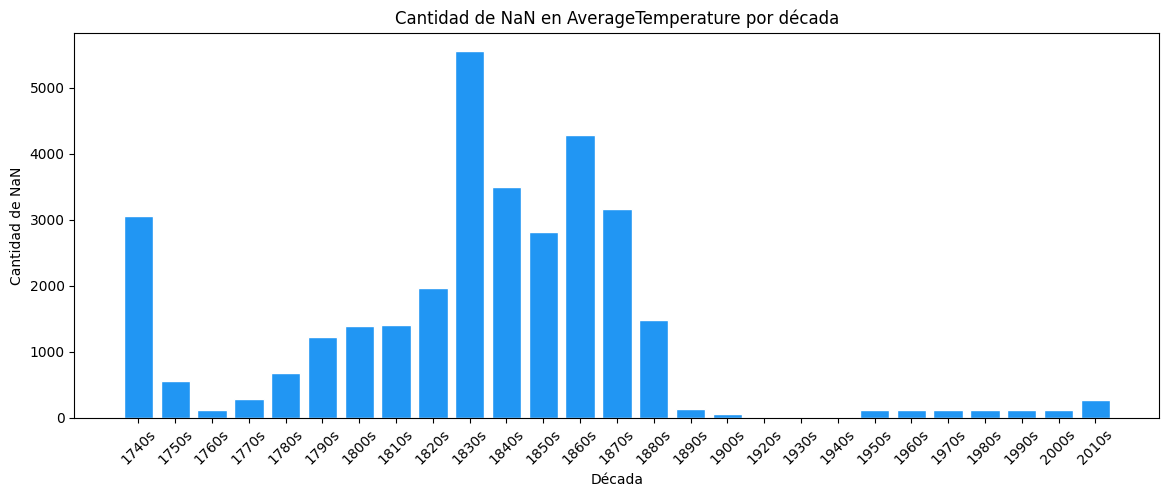

In [6]:
df["decade"] = (df["year"] // 10) * 10
df_nans_decade = df[df["AverageTemperature"].isna()].groupby("decade").size()

fig, ax = plt.subplots(figsize=(14, 5))
decades = df_nans_decade.index.astype(str) + "s"
ax.bar(decades, df_nans_decade.values, color="#2196F3", edgecolor="white")
ax.set_title("Cantidad de NaN en AverageTemperature por década")
ax.set_xlabel("Década")
ax.set_ylabel("Cantidad de NaN")
plt.xticks(rotation=45)
plt.show()

En este resultado vemos que una gran parte de los `NaN` son de los años $ 1750\to 1850 $. 
Esto indica que las mediciones en esas fechas son escasas.

Algunas alternativas son:
- Quitarlas simplemente
- Rellenarlas tomando el punto siguiente y el anterior y sacar el punto medio, ya que son datos de temperatura, que siguen ciclos
- En útimo caso usar la distribución de los datos, lo cual no es óptimo, y no es muy buena idea, ya que la temperatura va según un ciclo.

Por otro lado, según el contexto hay otras incidencias para `1940` por el cambio de estaciones meteorológicas, y para `1980` el cambio de termómetros de mercurio a electrónicos. Se visualizará la incertidumbre de los datos a lo largo del tiempo para verificar su calidad.

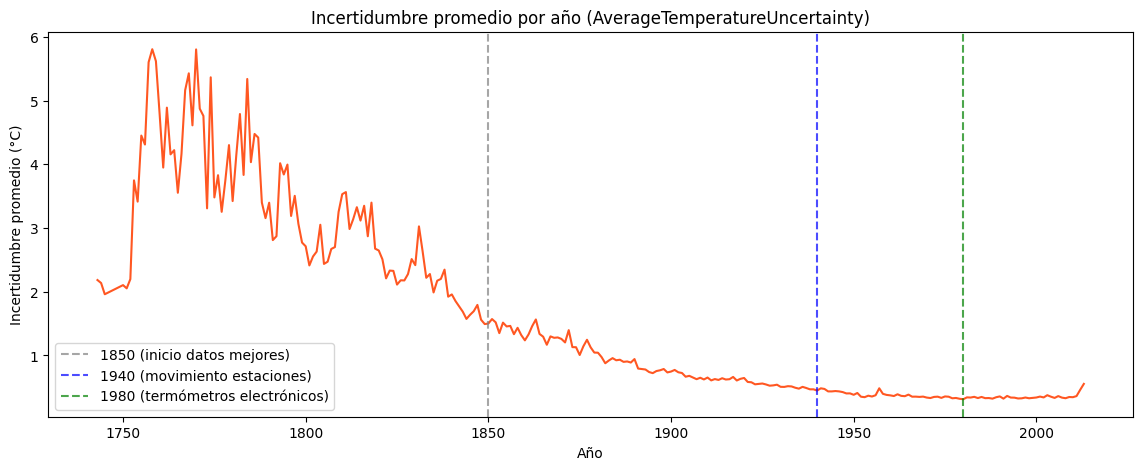

In [7]:
df_valid = df.dropna(subset=["AverageTemperature", "AverageTemperatureUncertainty"])
unc_by_year = df_valid.groupby("year")["AverageTemperatureUncertainty"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(unc_by_year.index, unc_by_year.values, color="#FF5722", linewidth=1.5)
ax.axvline(x=1850, color="gray", linestyle="--", alpha=0.7, label="1850 (inicio datos mejores)")
ax.axvline(x=1940, color="blue", linestyle="--", alpha=0.7, label="1940 (movimiento estaciones)")
ax.axvline(x=1980, color="green", linestyle="--", alpha=0.7, label="1980 (termómetros electrónicos)")
ax.set_title("Incertidumbre promedio por año (AverageTemperatureUncertainty)")
ax.set_xlabel("Año")
ax.set_ylabel("Incertidumbre promedio (°C)")
ax.legend()
plt.show()

La gráfica confirma que antes de 1850 la incertidumbre era extremadamente alta. A partir de 1850 la calidad mejora drásticamente y luego sigue un descenso progresivo. 

También es importante revisar si hay países que no tengan datos útiles.

In [8]:
nans_by_country = df[df["AverageTemperature"].isna()].groupby("Country").size()
total_by_country = df.groupby("Country").size()
pct_nan_by_country = (nans_by_country / total_by_country * 100).sort_values(ascending=False)

print("Top 10 países con mayor porcentaje de NaN:")
print(pct_nan_by_country.head(10))

Top 10 países con mayor porcentaje de NaN:
Country
Antarctica    100.000000
Mauritius      38.184491
Reunion        38.184491
Mayotte        35.207644
Madagascar     35.207644
Comoros        35.207644
Seychelles     35.207644
Niger          25.075011
Tanzania       18.829517
Bahamas        18.650147
dtype: float64


Vemos que **Antarctica** tiene 100% de datos faltantes, por lo que no aporta valor al análisis.

---

# Limpieza y Preparación del Dataset

Con base en la investigación anterior, se procederá a limpiar el dataset para garantizar la calidad de los resultados en los análisis posteriores:

1. **Descartar registros pre-1850**: Debido a su altísima incertidumbre.
2. **Excluir a la Antártida**: Ya que el 100% de sus registros son nulos.
3. **Eliminar valores nulos**: Quitar las filas con `NaN` en la temperatura.
4. **Filtrar por incertidumbre**: Eliminar mediciones con una incertidumbre anómalamente alta. Se usará un umbral de 3.42 °C (correspondiente a la media más dos desviaciones estándar del período válido).

In [9]:
print(f"Filas iniciales: {len(df)}")

# 1. Eliminar datos anteriores a 1850
df_clean = df[df["dt"].dt.year >= 1850].copy()
print(f"Filas tras filtro pre-1850: {len(df_clean)}")

# 2. Excluir Antarctica
df_clean = df_clean[df_clean["Country"] != "Antarctica"]
print(f"Filas tras excluir Antártida: {len(df_clean)}")

# 3. Eliminar NaN en AverageTemperature
df_clean = df_clean.dropna(subset=["AverageTemperature"])
print(f"Filas tras eliminar NaN: {len(df_clean)}")

# 4. Filtrar por alta incertidumbre (> 3.42°C)
df_clean = df_clean[df_clean["AverageTemperatureUncertainty"] <= 3.42]
print(f"Filas finales tras filtro de incertidumbre: {len(df_clean)}")

eliminadas = len(df) - len(df_clean)
print(f"\nSe eliminaron {eliminadas} filas en total ({(eliminadas)/len(df)*100:.2f}%).")

Filas iniciales: 577462
Filas tras filtro pre-1850: 465370
Filas tras excluir Antártida: 464606
Filas tras eliminar NaN: 452458
Filas finales tras filtro de incertidumbre: 451687

Se eliminaron 125775 filas en total (21.78%).


Finalmente, guardamos el dataset limpio en un nuevo archivo CSV para ser utilizado en el código de visualización.

In [10]:
df_clean.drop(columns=["year", "decade"], inplace=True, errors='ignore')
df_clean.to_csv("GlobalLandTemperaturesByCountry_cleaned.csv", index=False)
print("Dataset limpio guardado exitosamente.")

Dataset limpio guardado exitosamente.
